In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('train_data.csv')

Text(0.5, 1.0, 'Raw Target (Skew: 68.01)')

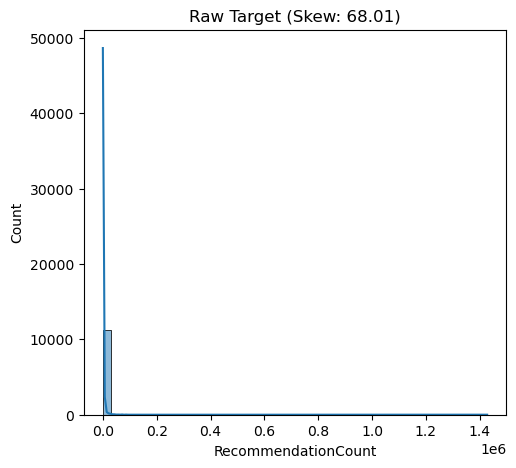

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['RecommendationCount'], bins=50, kde=True)
plt.title(f"Raw Target (Skew: {df['RecommendationCount'].skew():.2f})")

High skewness, apply log transform to compress extreme ranges

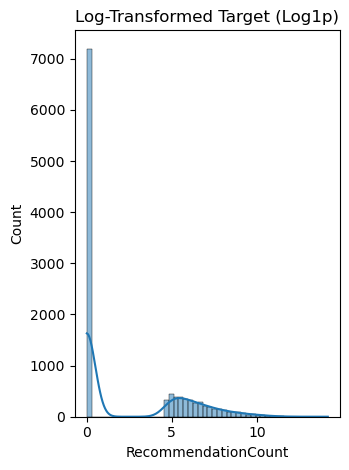

In [6]:
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['RecommendationCount']), bins=50, kde=True)
plt.title("Log-Transformed Target (Log1p)")
plt.tight_layout()
plt.show()

In [7]:
num_df = df.select_dtypes(include=['number'])

continuous_cols = []
discrete_cols = []
for col in num_df.columns:
    unique_ratio = df[col].nunique() / len(df)
    if unique_ratio > 0.05:
        continuous_cols.append(col)
    else:
        discrete_cols.append(col)

print(f"Continuous Columns: {continuous_cols}")
print(f"Discrete/Categorical Numerical: {discrete_cols}")

Continuous Columns: ['QueryID', 'ResponseID', 'RecommendationCount', 'SteamSpyOwners', 'SteamSpyOwnersVariance', 'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance']
Discrete/Categorical Numerical: ['RequiredAge', 'DemoCount', 'DeveloperCount', 'DLCCount', 'Metacritic', 'MovieCount', 'PackageCount', 'PublisherCount', 'ScreenshotCount', 'AchievementCount', 'AchievementHighlightedCount', 'PriceInitial', 'PriceFinal']


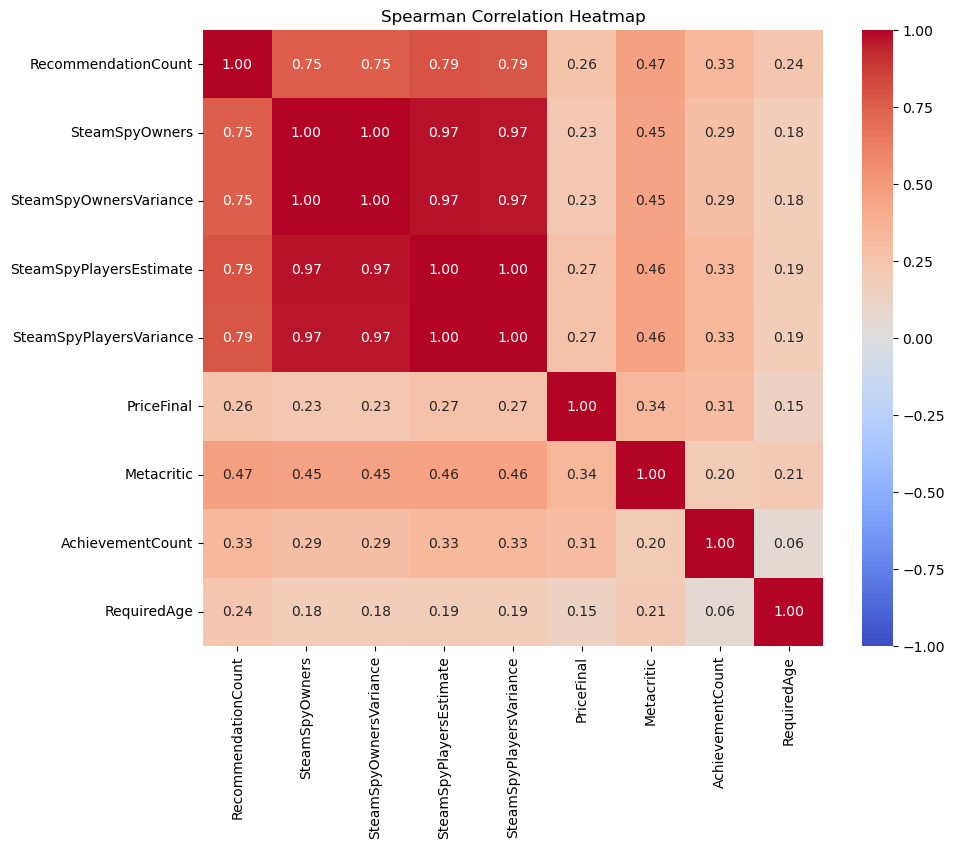

In [10]:
numerical_cols = ['RecommendationCount', 'SteamSpyOwners', 'SteamSpyOwnersVariance', 'SteamSpyPlayersEstimate','SteamSpyPlayersVariance', 'PriceFinal','Metacritic', 'AchievementCount', 'RequiredAge']
# spearman correlation (for non-linear relations)
corr_matrix = df[numerical_cols].corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Spearman Correlation Heatmap")
plt.show()

In [11]:
df['Log_Recs'] = np.log1p(df['RecommendationCount'])
non_zero_games = df[df['RecommendationCount'] > 0].copy()

This EDA suite is designed to visually expose how specific game features, language support statistically influence your skewed recommendation data. identifies non-linear patterns and "signal" strengths to help select which variables are actually worth including

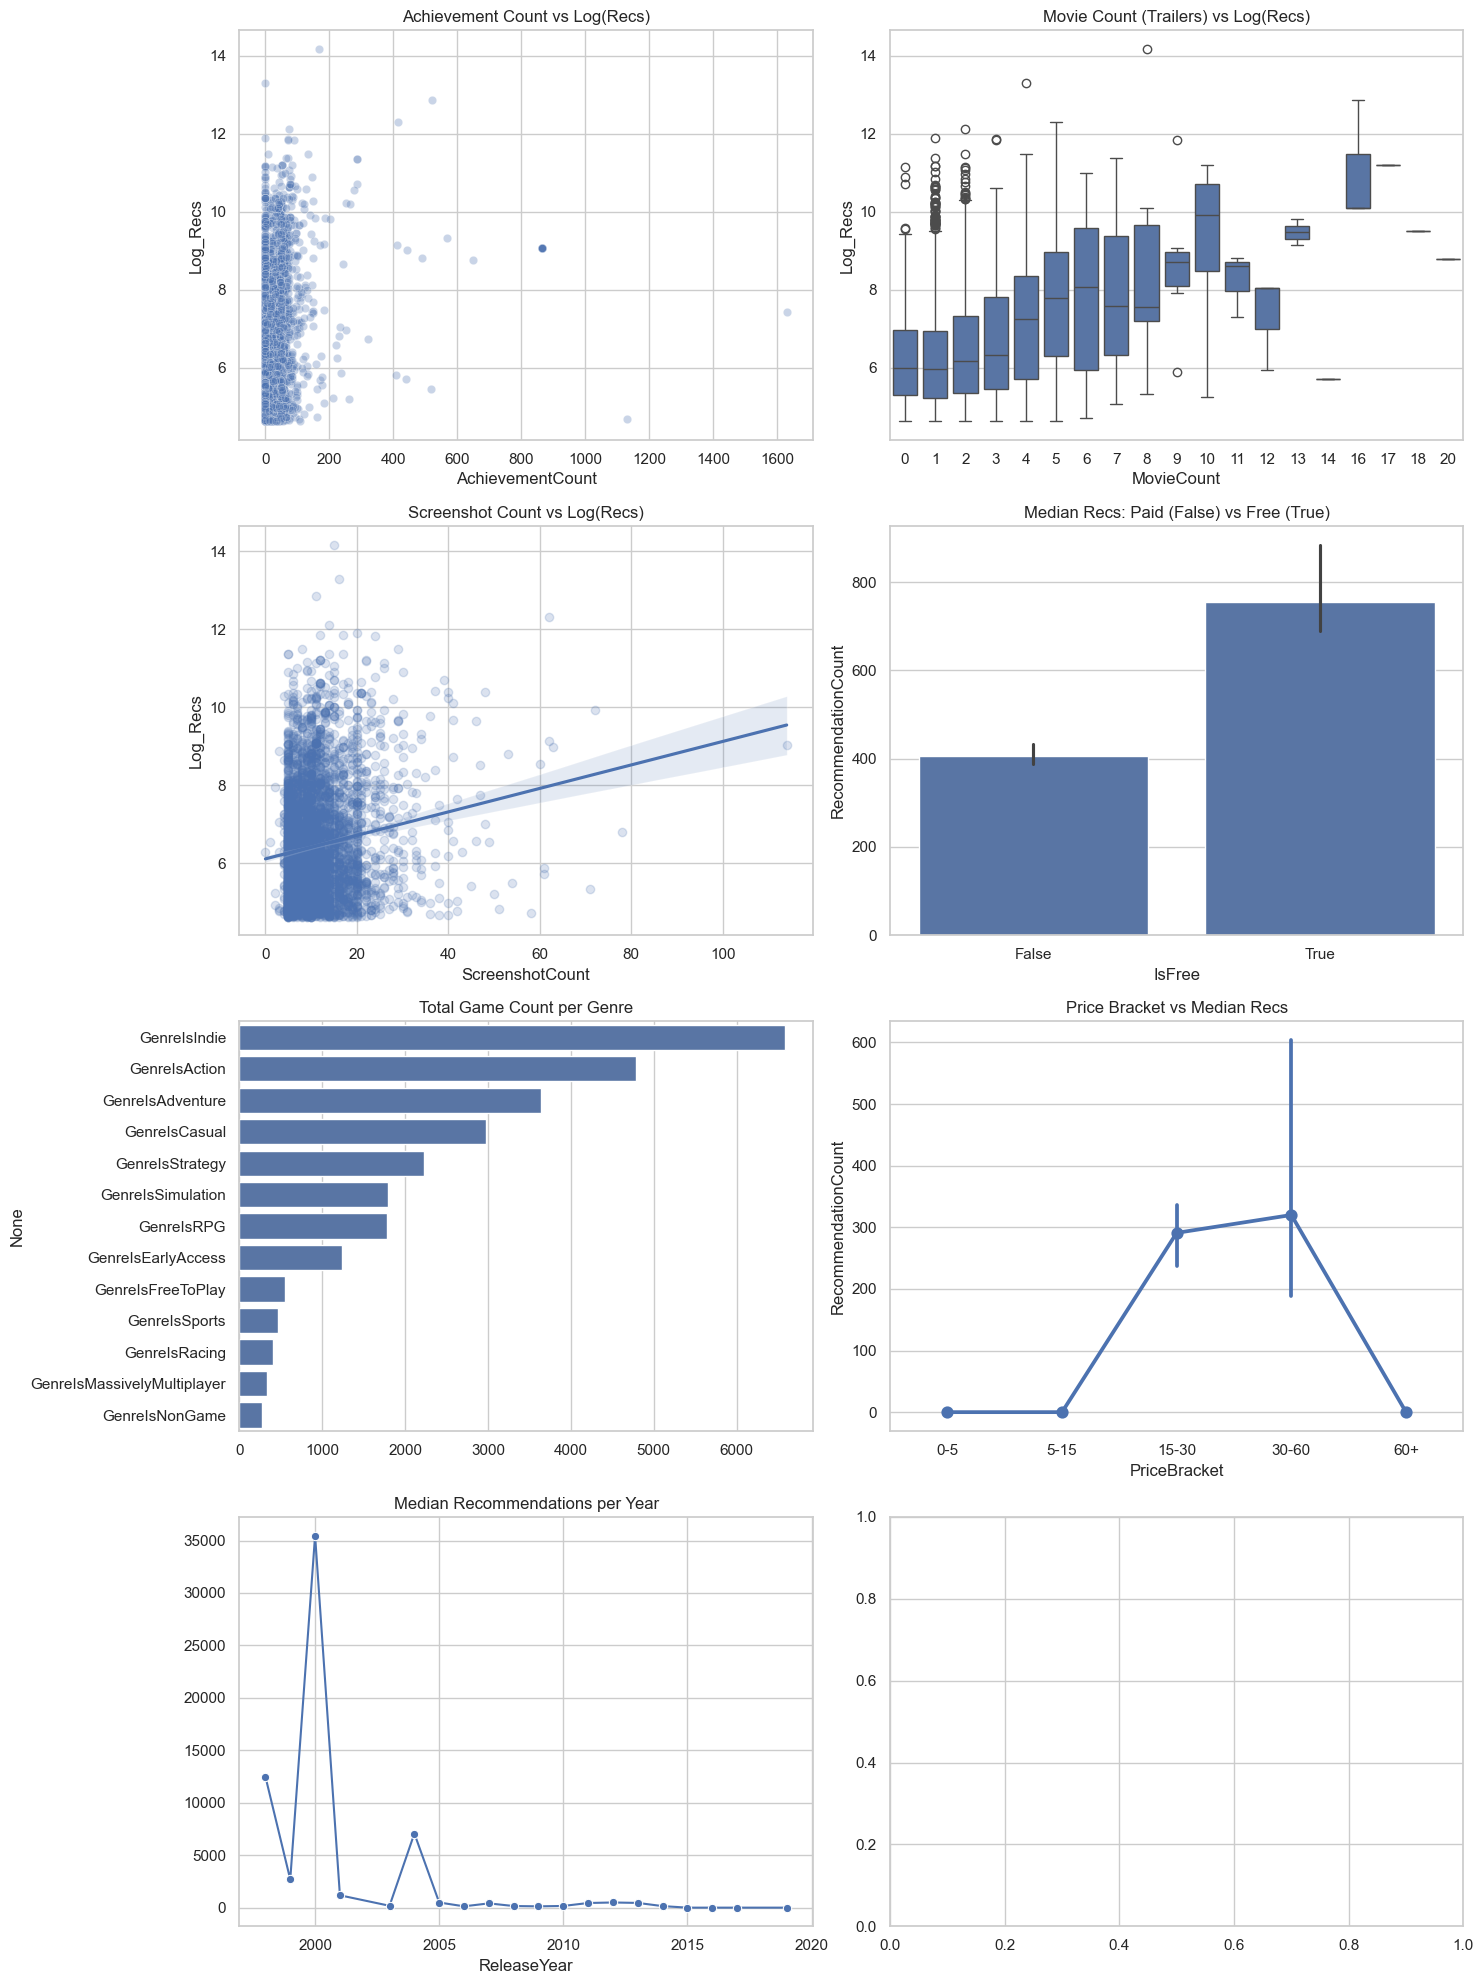

In [17]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 20)

fig, axes = plt.subplots(4, 2)
axes = axes.flatten()

sns.scatterplot(data=non_zero_games, x='AchievementCount', y='Log_Recs', alpha=0.3, ax=axes[0])
axes[0].set_title("Achievement Count vs Log(Recs)")

sns.boxplot(data=non_zero_games, x='MovieCount', y='Log_Recs', ax=axes[1])
axes[1].set_title("Movie Count (Trailers) vs Log(Recs)")

sns.regplot(data=non_zero_games, x='ScreenshotCount', y='Log_Recs', scatter_kws={'alpha':0.2}, ax=axes[2])
axes[2].set_title("Screenshot Count vs Log(Recs)")

sns.barplot(data=non_zero_games, x='IsFree', y='RecommendationCount', estimator=np.median, ax=axes[3])
axes[3].set_title("Median Recs: Paid (False) vs Free (True)")

genre_cols = [col for col in df.columns if 'GenreIs' in col]
genre_counts = df[genre_cols].sum().sort_values(ascending=False)
sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[4])
axes[4].set_title("Total Game Count per Genre")

df['PriceBracket'] = pd.cut(df['PriceFinal'], bins=[0, 5, 15, 30, 60, 200], labels=['0-5', '5-15', '15-30', '30-60', '60+'])
sns.pointplot(data=df, x='PriceBracket', y='RecommendationCount', estimator=np.median, ax=axes[5])
axes[5].set_title("Price Bracket vs Median Recs")

df['ReleaseYear'] = pd.to_datetime(df['ReleaseDate'], errors='coerce').dt.year
year_data = df.groupby('ReleaseYear')['RecommendationCount'].median()
sns.lineplot(x=year_data.index, y=year_data.values, marker='o', ax=axes[6])
axes[6].set_title("Median Recommendations per Year")

plt.tight_layout()
plt.show()

# p.s.
movie & screenshot counts --> positive trend with RecNumber

price vs median RecNumber --> popularity peaks in the 15-60 range (!free games)

median recs (IsFree): free games have double the median recommendation count compared to paid games
